In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [17]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [18]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

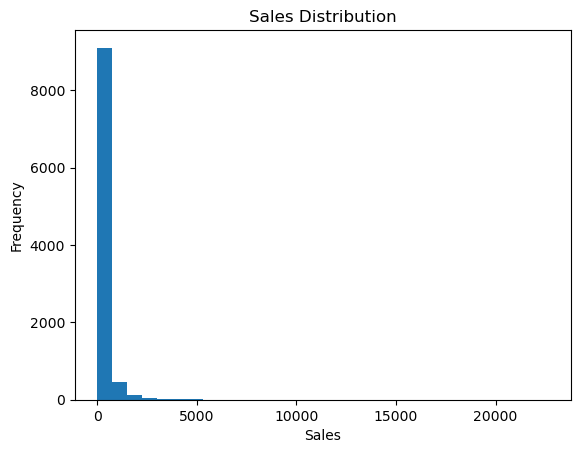

In [20]:
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

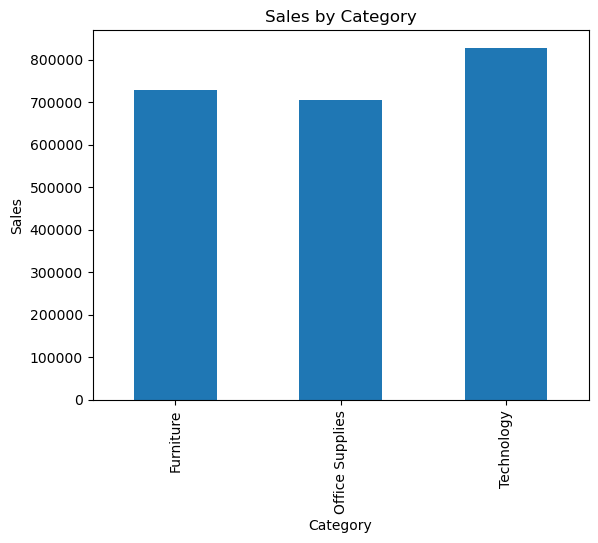

In [21]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

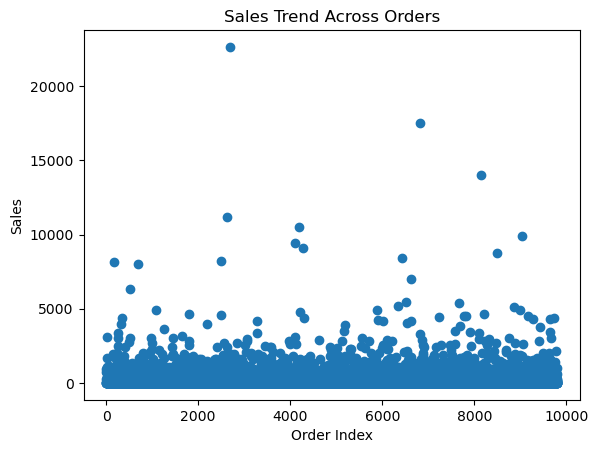

In [22]:
plt.scatter(df.index, df['Sales'])

plt.title("Sales Trend Across Orders")
plt.xlabel("Order Index")
plt.ylabel("Sales")
plt.show()

In [23]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

print(Q1, Q3, IQR)

17.248 210.60500000000002 193.35700000000003


In [24]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-272.7875000000001 500.6405000000001


In [25]:
outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
outliers

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840
11,12,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9759,9760,CA-2017-146913,31/10/2017,05/11/2017,Standard Class,SF-20965,Sylvia Foulston,Corporate,United States,San Francisco,California,94109.0,West,FUR-CH-10001854,Furniture,Chairs,Office Star - Professional Matrix Back Chair w...,1403.9200
9774,9775,CA-2015-169019,26/07/2015,30/07/2015,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,Texas,78207.0,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.5840
9781,9782,CA-2017-153178,14/09/2017,18/09/2017,Standard Class,CL-12565,Clay Ludtke,Consumer,United States,Long Beach,New York,11561.0,East,OFF-BI-10004390,Office Supplies,Binders,GBC DocuBind 200 Manual Binding Machine,673.5680
9787,9788,CA-2018-144491,27/03/2018,01/04/2018,Standard Class,CJ-12010,Caroline Jumper,Consumer,United States,Houston,Texas,77070.0,Central,FUR-BO-10001811,Furniture,Bookcases,"Atlantic Metals Mobile 5-Shelf Bookcases, Cust...",1023.3320


In [26]:
df_clean = df[(df['Sales'] >= lower) & (df['Sales'] <= upper)]

In [27]:
df_sample = df.sample(1000)

In [28]:
df_reduced = df.drop(['Postal Code', 'Customer Name'], axis=1)

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Sales_MinMax'] = scaler.fit_transform(df[['Sales']])

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Sales_Z'] = scaler.fit_transform(df[['Sales']])

In [31]:
df['Sales_Category'] = pd.cut(df['Sales'], bins=3, labels=['Low', 'Medium', 'High'])
df[['Sales', 'Sales_Category']].head()

,Sales,Sales_Category
0,261.9600,Low
1,731.9400,Low
2,14.6200,Low
3,957.5775,Low
4,22.3680,Low


In [32]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Row ID          9800 non-null   int64   
 1   Order ID        9800 non-null   object  
 2   Order Date      9800 non-null   object  
 3   Ship Date       9800 non-null   object  
 4   Ship Mode       9800 non-null   object  
 5   Customer ID     9800 non-null   object  
 6   Customer Name   9800 non-null   object  
 7   Segment         9800 non-null   object  
 8   Country         9800 non-null   object  
 9   City            9800 non-null   object  
 10  State           9800 non-null   object  
 11  Postal Code     9800 non-null   float64 
 12  Region          9800 non-null   object  
 13  Product ID      9800 non-null   object  
 14  Category        9800 non-null   object  
 15  Sub-Category    9800 non-null   object  
 16  Product Name    9800 non-null   object  
 17  Sales         

,Row ID,Postal Code,Sales,Sales_MinMax,Sales_Z
count,9800.000000,9800.000000,9800.000000,9800.000000,9.800000e+03
mean,4900.500000,55273.322403,230.769059,0.010174,1.848861e-17
std,2829.160653,32023.234209,626.651875,0.027681,1.000051e+00
min,1.000000,1040.000000,0.444000,0.000000,-3.675674e-01
25%,2450.750000,23223.000000,17.248000,0.000742,-3.407505e-01
50%,4900.500000,57551.000000,54.490000,0.002387,-2.813174e-01
75%,7350.250000,90008.000000,210.605000,0.009284,-3.217909e-02
max,9800.000000,99301.000000,22638.480000,1.000000,3.575965e+01


In [33]:
df['Sales'].mean()
df['Sales'].median()
df['Sales'].mode()[0]
df['Sales'].min()
df['Sales'].max()

22638.48

In [34]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Sales_MinMax,Sales_Z
Row ID,1.000000,0.013629,0.001151,0.001151,0.001151
Postal Code,0.013629,1.000000,-0.024002,-0.024002,-0.024002
Sales,0.001151,-0.024002,1.000000,1.000000,1.000000
Sales_MinMax,0.001151,-0.024002,1.000000,1.000000,1.000000
Sales_Z,0.001151,-0.024002,1.000000,1.000000,1.000000
